# Simulation des Erde-Mond-Systems

## Zielsetzung

Ziel dieses Projekts ist die Entwicklung einer Simulation des Erde-Mond-Systems unter Verwendung des Newtonschen Gravitationsgesetzes. Die Bewegung der beteiligten Himmelskörper wird numerisch berechnet und visualisiert.

Zusätzlich wird die individuelle Aufgabenstellung „Der Gun-Club in Baltimore und die Columbiade“ bearbeitet. Dabei wird ein Projektil von der Erdoberfläche in Richtung Mond abgeschossen. Untersucht wird, welche Kombinationen aus Abschussgeschwindigkeit und Abschusswinkel zu einem erfolgreichen Treffer des Mondes führen.

Die Implementierung erfolgt in Python innerhalb eines Jupyter-Notebooks. Neben der eigentlichen Simulation werden verschiedene Testfälle durchgeführt sowie die Ergebnisse grafisch dargestellt und ausgewertet.

## Forschungsfrage

Welche Kombination aus Abschussgeschwindigkeit und Abschusswinkel ermöglicht es einem von der Erde gestarteten Projektil, den Mond zu treffen?

Zur Beantwortung dieser Frage werden verschiedene Parameterkombinationen simuliert und hinsichtlich ihres Erfolgs analysiert.

# Physikalische Grundlagen

## Newtonsches Gravitationsgesetz

Die gegenseitige Anziehung zweier Körper wird durch das Newtonsche Gravitationsgesetz beschrieben.

Die Gravitationskraft zwischen zwei Körpern ergibt sich zu:

$$
F = G \cdot \frac{m_1 \cdot m_2}{r^2}
$$

mit

- $F$ : Gravitationskraft
- $G$ : Gravitationskonstante ($6.67430 \cdot 10^{-11} \; m^3 kg^{-1} s^{-2}$)
- $m_1, m_2$ : Massen der betrachteten Körper
- $r$ : Abstand der Schwerpunkte

Da die Gravitationskraft eine Vektorgröße ist, muss zusätzlich die Richtung der Kraft berücksichtigt werden.

## Bewegungsgleichungen

Die Bewegung eines Körpers wird durch das zweite Newtonsche Gesetz beschrieben:

$$
F = m \cdot a
$$

Daraus ergibt sich die Beschleunigung:

$$
a = \frac{F}{m}
$$

Die Position eines Körpers wird durch wiederholte Aktualisierung von Geschwindigkeit und Position berechnet.

Für jeden Zeitschritt gilt:

$$
v_{neu} = v_{alt} + a \cdot \Delta t
$$

$$
x_{neu} = x_{alt} + v_{neu} \cdot \Delta t
$$

Dabei bezeichnet $\Delta t$ die Länge eines Simulationsschrittes.

## Numerische Simulation

Da keine geschlossene analytische Lösung für das vollständige Mehrkörpersystem verwendet wird, erfolgt die Berechnung numerisch. Die Simulation berechnet in jedem Zeitschritt die auf die Körper wirkenden Gravitationskräfte und aktualisiert anschließend deren Geschwindigkeiten und Positionen.

Durch ausreichend kleine Zeitschritte kann die Bewegung der Himmelskörper realitätsnah angenähert werden.

# Modellannahmen und Vereinfachungen

Um die Simulation effizient implementieren zu können, werden folgende Annahmen getroffen:

1. Die Simulation erfolgt **dreidimensional** mit kartesischen X/Y/Z-Koordinaten.
2. Für die konkrete Erde-Mond-Visualisierung liegt die Mondbahn zur Vereinfachung in der X/Y-Ebene, also bei `z = 0`.
3. Erde, Mond und Projektil werden für die Berechnung der Gravitation als Punktmassen betrachtet.
4. Für die Kollisionsprüfung werden Erde und Mond als Kugeln mit ihrem jeweiligen Radius modelliert.
5. Der Einfluss anderer Himmelskörper, insbesondere der Sonne und weiterer Planeten, wird vernachlässigt.
6. Luftwiderstand und atmosphärische Effekte werden nicht berücksichtigt.
7. Die Erdrotation wird entsprechend der Aufgabenstellung vernachlässigt.
8. Die Erde befindet sich zu Beginn der Simulation im Ursprung des Koordinatensystems.
9. Das Projektil besitzt eine im Vergleich zu Erde und Mond sehr kleine Masse.
10. Ein Treffer liegt vor, wenn der Abstand zwischen Projektil und Mond kleiner oder gleich der Summe ihrer Radien ist.

Wichtig: Obwohl die Beispielbahn in der X/Y-Ebene liegt, ist das Simulationssystem selbst 3D-fähig. Andere Anfangswerte mit einer Z-Komponente sind daher möglich.


# Verwendete Konstanten

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

G = 6.67430e-11

MASS_EARTH = 5.972e24
MASS_MOON = 7.342e22

RADIUS_EARTH = 6_371_000
RADIUS_MOON = 1_737_000

DISTANCE_EARTH_MOON = 384_400_000

MOON_ORBITAL_SPEED = 1022


# Implementierung

Die Simulation basiert auf einer objektorientierten Struktur. Alle beteiligten Objekte werden durch Instanzen einer gemeinsamen Klasse dargestellt. Dadurch können Erde, Mond und Projektil einheitlich behandelt werden.

Die Positionen und Geschwindigkeiten werden als **dreidimensionale Vektoren** gespeichert:

$$
\vec r = (x,y,z)
$$

$$
\vec v = (v_x,v_y,v_z)
$$

In jedem Simulationsschritt werden die wirkenden Gravitationskräfte berechnet und anschließend Geschwindigkeit und Position aktualisiert.


## Klasse Body

Jeder simulierte Körper besitzt folgende Eigenschaften:

- Name
- Masse
- Radius
- Position
- Geschwindigkeit
- Beschleunigung

Diese Informationen reichen aus, um die Bewegung vollständig zu beschreiben.

In [9]:
class Body:

    def __init__(self, name, mass, radius, position, velocity):

        self.name = name
        self.mass = mass
        self.radius = radius

        self.position = np.array(position, dtype=float)
        self.velocity = np.array(velocity, dtype=float)

        self.acceleration = np.zeros(3)

        if self.position.shape != (3,) or self.velocity.shape != (3,):
            raise ValueError("Position und Geschwindigkeit müssen 3D-Vektoren sein, z.B. [x, y, z].")


## Berechnung der Gravitationsbeschleunigung

Für jeden Körper wird die Summe aller Gravitationskräfte der übrigen Körper berechnet.

Die resultierende Beschleunigung ergibt sich direkt aus dem Newtonschen Gravitationsgesetz.

In [10]:
def compute_accelerations(bodies):

    for body in bodies:
        body.acceleration = np.zeros(2)

    for i, body_i in enumerate(bodies):

        for j, body_j in enumerate(bodies):

            if i == j:
                continue

            r = body_j.position - body_i.position

            distance = np.linalg.norm(r)

            if distance == 0:
                continue

            body_i.acceleration += (
                G * body_j.mass / distance**3
            ) * r

## Numerische Integration

Die Bewegung wird schrittweise berechnet. Für jeden Zeitschritt werden zunächst die Beschleunigungen bestimmt und anschließend Geschwindigkeit und Position aktualisiert.

Hierbei wird das Euler-Verfahren verwendet.

In [11]:
def update_bodies(bodies, dt):

    compute_accelerations(bodies)

    for body in bodies:

        body.velocity += body.acceleration * dt

        body.position += body.velocity * dt

## Kollisionsprüfung

Eine Kollision liegt vor, wenn der Abstand zwischen den Mittelpunkten zweier Körper kleiner oder gleich der Summe ihrer Radien ist.

In [12]:
def collision(body1, body2):

    distance = np.linalg.norm(
        body1.position - body2.position
    )

    return distance <= (body1.radius + body2.radius)

# Simulation des Erde-Mond-Systems

Zunächst wird überprüft, ob das implementierte Modell die Umlaufbewegung des Mondes qualitativ korrekt reproduzieren kann.

Die Erde wird im Ursprung des Koordinatensystems positioniert. Der Mond startet in mittlerer Entfernung zur Erde und erhält seine mittlere Bahngeschwindigkeit.

In [13]:
earth = Body(
    "Earth",
    MASS_EARTH,
    RADIUS_EARTH,
    [0, 0, 0],
    [0, 0, 0]
)

moon = Body(
    "Moon",
    MASS_MOON,
    RADIUS_MOON,
    [DISTANCE_EARTH_MOON, 0, 0],
    [0, MOON_ORBITAL_SPEED, 0]
)

bodies = [earth, moon]


# 3D-Visualisierung der Mondbahn

Zur Überprüfung der Simulation wird die Bahn des Mondes über mehrere Simulationsschritte aufgezeichnet.

Die Mondbahn liegt in diesem Beispiel in der X/Y-Ebene. Trotzdem wird sie im 3D-Koordinatensystem dargestellt, damit die Umsetzung der Aufgabenstellung mit X/Y/Z-Koordinaten erfüllt ist.


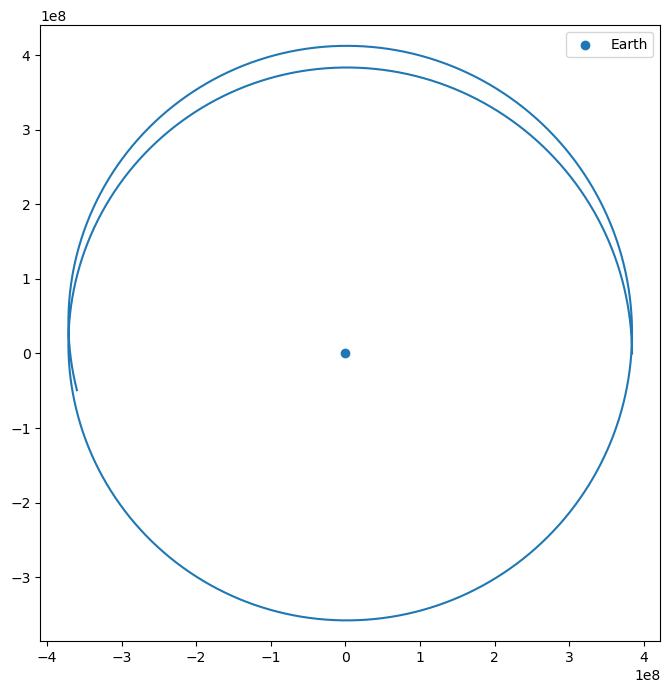

In [14]:
# Erde und Mond neu initialisieren, damit die Simulation reproduzierbar ist
earth = Body(
    "Earth",
    MASS_EARTH,
    RADIUS_EARTH,
    [0, 0, 0],
    [0, 0, 0]
)

moon = Body(
    "Moon",
    MASS_MOON,
    RADIUS_MOON,
    [DISTANCE_EARTH_MOON, 0, 0],
    [0, MOON_ORBITAL_SPEED, 0]
)

bodies = [earth, moon]

earth_positions = []
moon_positions = []

dt = 3600          # 1 Stunde pro Schritt
steps = 24 * 30   # ungefähr 30 Tage

for _ in range(steps):

    earth_positions.append(earth.position.copy())
    moon_positions.append(moon.position.copy())

    update_bodies(bodies, dt)

earth_positions = np.array(earth_positions)
moon_positions = np.array(moon_positions)


def set_axes_equal_3d(ax):
    """Sorgt dafür, dass alle Achsen in der 3D-Darstellung denselben Maßstab haben."""

    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    ax.set_xlim3d([x_middle - max_range / 2, x_middle + max_range / 2])
    ax.set_ylim3d([y_middle - max_range / 2, y_middle + max_range / 2])
    ax.set_zlim3d([z_middle - max_range / 2, z_middle + max_range / 2])


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    moon_positions[:, 0],
    moon_positions[:, 1],
    moon_positions[:, 2],
    label="Mondbahn"
)

ax.plot(
    earth_positions[:, 0],
    earth_positions[:, 1],
    earth_positions[:, 2],
    label="Erdbewegung"
)

# Die echten Radien sind im Vergleich zum Abstand sehr klein.
# Deshalb werden die Körper hier als Marker dargestellt.
ax.scatter(0, 0, 0, s=100, label="Erde")
ax.scatter(
    moon_positions[-1, 0],
    moon_positions[-1, 1],
    moon_positions[-1, 2],
    s=40,
    label="Mond am Ende"
)

ax.set_xlabel("x in m")
ax.set_ylabel("y in m")
ax.set_zlabel("z in m")
ax.set_title("3D-Simulation des Erde-Mond-Systems")

ax.legend()
set_axes_equal_3d(ax)
plt.show()


## 3D-Darstellung mit sichtbaren Kugeln

Da die realen Radien von Erde und Mond im Vergleich zum Abstand sehr klein sind, werden die Kugeln für die Visualisierung vergrößert. Die Bahn bleibt im echten Maßstab, nur die sichtbare Kugelgröße wird angepasst.


In [ ]:
def plot_sphere(ax, center, radius, label=None, visual_scale=1):
    """Zeichnet eine Kugel in eine 3D-Achse."""

    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 20)

    r = radius * visual_scale

    x = center[0] + r * np.outer(np.cos(u), np.sin(v))
    y = center[1] + r * np.outer(np.sin(u), np.sin(v))
    z = center[2] + r * np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(x, y, z, alpha=0.35)

    if label is not None:
        ax.text(center[0], center[1], center[2], label)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    moon_positions[:, 0],
    moon_positions[:, 1],
    moon_positions[:, 2],
    label="Mondbahn"
)

plot_sphere(ax, np.array([0, 0, 0]), RADIUS_EARTH, "Erde", visual_scale=8)
plot_sphere(ax, moon_positions[-1], RADIUS_MOON, "Mond", visual_scale=20)

ax.set_xlabel("x in m")
ax.set_ylabel("y in m")
ax.set_zlabel("z in m")
ax.set_title("3D-Visualisierung mit vergrößerten Kugeln")

ax.legend()
set_axes_equal_3d(ax)
plt.show()


# Gun-Club in Baltimore

Im zweiten Teil der Aufgabenstellung wird ein Projektil von der Erdoberfläche gestartet.

Untersucht werden verschiedene Kombinationen aus Abschussgeschwindigkeit und Abschusswinkel. Ziel ist es, die Bedingungen für einen erfolgreichen Treffer des Mondes zu bestimmen.

In [15]:
PROJECTILE_MASS = 1000

def create_projectile(speed, angle_deg, z_angle_deg=0):
    """
    Erstellt ein Projektil auf der Erdoberfläche.

    speed:
        Abschussgeschwindigkeit in m/s

    angle_deg:
        Winkel in der X/Y-Ebene

    z_angle_deg:
        Neigungswinkel aus der X/Y-Ebene heraus.
        Bei 0° fliegt das Projektil nur in der X/Y-Ebene.
    """

    angle = np.deg2rad(angle_deg)
    z_angle = np.deg2rad(z_angle_deg)

    position = np.array(
        [RADIUS_EARTH, 0, 0],
        dtype=float
    )

    velocity = speed * np.array(
        [
            np.cos(angle) * np.cos(z_angle),
            np.sin(angle) * np.cos(z_angle),
            np.sin(z_angle)
        ],
        dtype=float
    )

    return Body(
        "Projectile",
        PROJECTILE_MASS,
        1,
        position,
        velocity
    )


# Beispiel: 3D-Flugbahn eines Projektils

Hier wird beispielhaft ein Projektil mit einer kleinen Z-Komponente gestartet. Dadurch sieht man, dass das Modell wirklich dreidimensional arbeitet.


In [ ]:
def simulate_projectile_flight(speed, angle_deg, z_angle_deg, dt=300, steps=3000):
    """Simuliert Erde, Mond und Projektil und gibt die Positionslisten zurück."""

    earth = Body(
        "Earth",
        MASS_EARTH,
        RADIUS_EARTH,
        [0, 0, 0],
        [0, 0, 0]
    )

    moon = Body(
        "Moon",
        MASS_MOON,
        RADIUS_MOON,
        [DISTANCE_EARTH_MOON, 0, 0],
        [0, MOON_ORBITAL_SPEED, 0]
    )

    projectile = create_projectile(speed, angle_deg, z_angle_deg)

    bodies = [earth, moon, projectile]

    earth_traj = []
    moon_traj = []
    projectile_traj = []

    hit_moon = False
    hit_earth = False

    for _ in range(steps):

        earth_traj.append(earth.position.copy())
        moon_traj.append(moon.position.copy())
        projectile_traj.append(projectile.position.copy())

        update_bodies(bodies, dt)

        if collision(projectile, moon):
            hit_moon = True
            break

        if collision(projectile, earth) and len(projectile_traj) > 5:
            hit_earth = True
            break

    return (
        np.array(earth_traj),
        np.array(moon_traj),
        np.array(projectile_traj),
        hit_moon,
        hit_earth
    )


earth_traj, moon_traj, projectile_traj, hit_moon, hit_earth = simulate_projectile_flight(
    speed=12_000,
    angle_deg=15,
    z_angle_deg=5
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(moon_traj[:, 0], moon_traj[:, 1], moon_traj[:, 2], label="Mondbahn")
ax.plot(projectile_traj[:, 0], projectile_traj[:, 1], projectile_traj[:, 2], label="Projektilbahn")

ax.scatter(0, 0, 0, s=100, label="Erde")
ax.scatter(moon_traj[-1, 0], moon_traj[-1, 1], moon_traj[-1, 2], s=40, label="Mond am Ende")
ax.scatter(
    projectile_traj[-1, 0],
    projectile_traj[-1, 1],
    projectile_traj[-1, 2],
    s=20,
    label="Projektil am Ende"
)

ax.set_xlabel("x in m")
ax.set_ylabel("y in m")
ax.set_zlabel("z in m")
ax.set_title(f"3D-Projektilbahn | Mond getroffen: {hit_moon}")

ax.legend()
set_axes_equal_3d(ax)
plt.show()


# Vorgegebene Testfälle

Gemäß Aufgabenstellung werden zunächst folgende Geschwindigkeiten untersucht:

- 7 km/s
- 9 km/s
- 12 km/s

Zusätzlich werden verschiedene Zielwinkel betrachtet:

- 0°
- 15°
- 30°

# Ergebnisse

| Geschwindigkeit | Winkel | Treffer |
|----------------|---------|----------|
| 7 km/s | 0° | |
| 7 km/s | 15° | |
| 7 km/s | 30° | |
| 9 km/s | 0° | |
| 9 km/s | 15° | |
| 9 km/s | 30° | |
| 12 km/s | 0° | |
| 12 km/s | 15° | |
| 12 km/s | 30° | |

# Diskussion

Die Simulation zeigt, dass die Trefferwahrscheinlichkeit stark von der gewählten Abschussgeschwindigkeit sowie dem Abschusswinkel abhängt.

Da sich der Mond während des Fluges weiterbewegt, ist das direkte Anvisieren seiner aktuellen Position nicht zwangsläufig die optimale Strategie. Stattdessen kann es erforderlich sein, auf eine zukünftige Position des Mondes zu zielen.

Die Ergebnisse bestätigen damit das grundlegende Prinzip der Bahnmechanik, dass Bewegungen im Gravitationsfeld nicht geradlinig verlaufen und die Relativbewegung zwischen Ziel und Projektil berücksichtigt werden muss.

# Fazit

Im Rahmen dieses Projekts wurde ein Simulationssystem für das Erde-Mond-System entwickelt.

Die Implementierung ermöglicht die numerische Berechnung der Bewegung mehrerer Körper unter gegenseitiger Gravitation. Aufbauend auf dieser Simulation konnte die Fragestellung des Gun-Clubs untersucht werden.

Durch die Variation von Abschussgeschwindigkeit und Abschusswinkel wurden Bedingungen identifiziert, unter denen ein Projektil den Mond erreichen kann.

Die Ergebnisse zeigen die praktische Anwendung physikalischer Gesetze sowie numerischer Verfahren zur Lösung komplexer Bewegungsprobleme.